In [11]:
import optuna
import dotenv
import os
dotenv.load_dotenv(dotenv_path="./../src/GradientGang/Pipeline/Optimizer/.env")
storage = (os.getenv("DATABASE_URL"))

In [12]:
storage

'REMOVED_KEY'

In [15]:
#create optuna study
study = optuna.create_study(direction="minimize", study_name="autoencoder_optimization", storage=storage, load_if_exists=True)

[I 2025-11-11 18:55:15,110] Using an existing study with name 'autoencoder_optimization' instead of creating a new one.


In [16]:
# Check study status
print(f"Study name: {study.study_name}")
print(f"Direction: {study.direction}")
print(f"Total trials: {len(study.trials)}")
print(f"Completed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Failed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
print(f"Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print(f"Running trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.RUNNING])}")

if len(study.trials) > 0:
    print("\nTrial states:")
    for i, trial in enumerate(study.trials[:10]):  # Show first 10 trials
        print(f"  Trial {i}: {trial.state}")
else:
    print("\n⚠️ No trials found in this study. You need to run the optimization first!")


Study name: autoencoder_optimization
Direction: 1
Total trials: 0
Completed trials: 0
Failed trials: 0
Pruned trials: 0
Running trials: 0

⚠️ No trials found in this study. You need to run the optimization first!


Study: autoencoder_optimization | Direction: 1 | Trials: 0


[W 2025-11-11 18:55:22,172] There are no complete trials.
c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\optuna\visualization\matplotlib\_optimization_history.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\optuna\visualization\matplotlib\_optimization_history.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
[W 2025-11-11 18:55:22,605] Study instance does not contain completed trials.
[W 2025-11-11 18:55:22,605] Study instance does not contain completed trials.
c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\optuna\visua

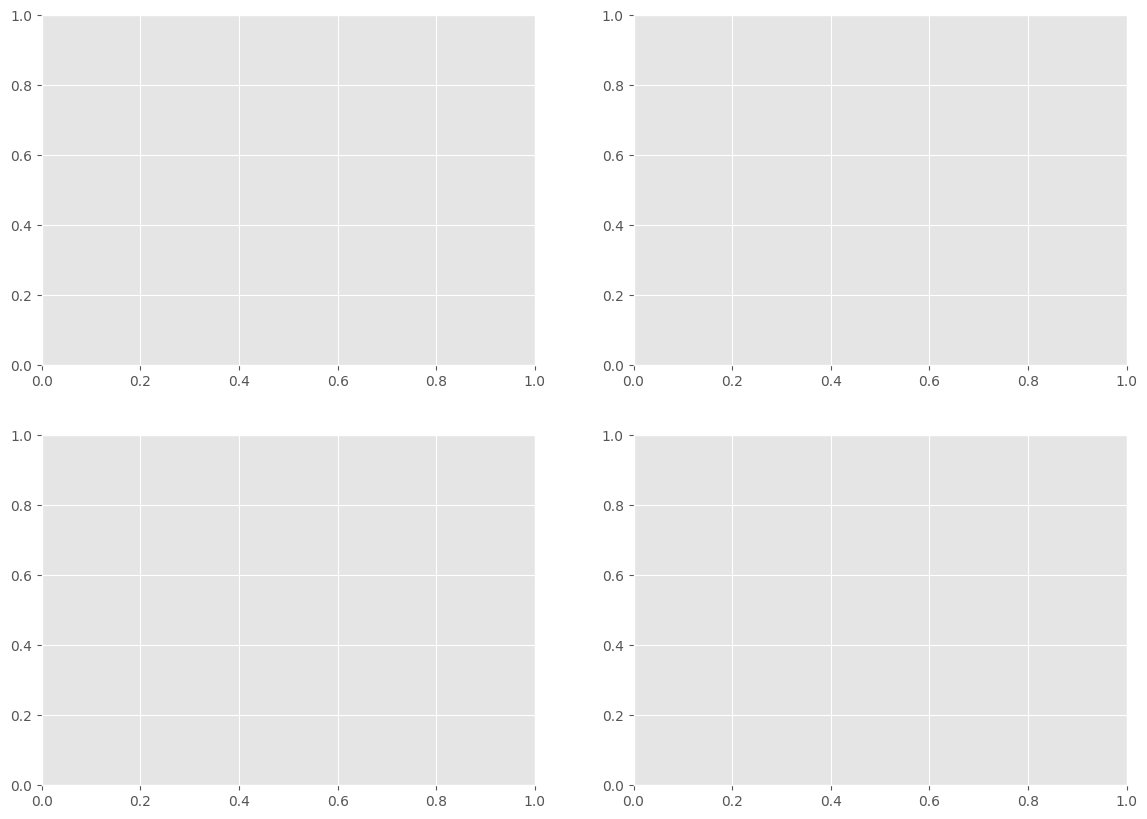

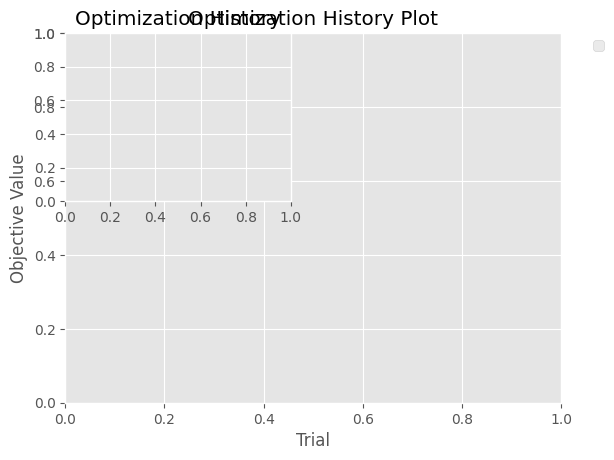

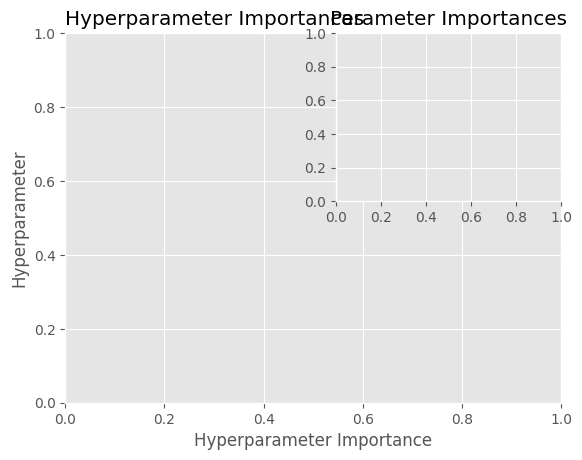

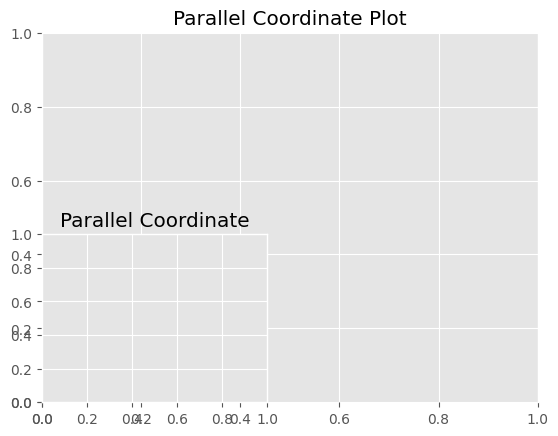

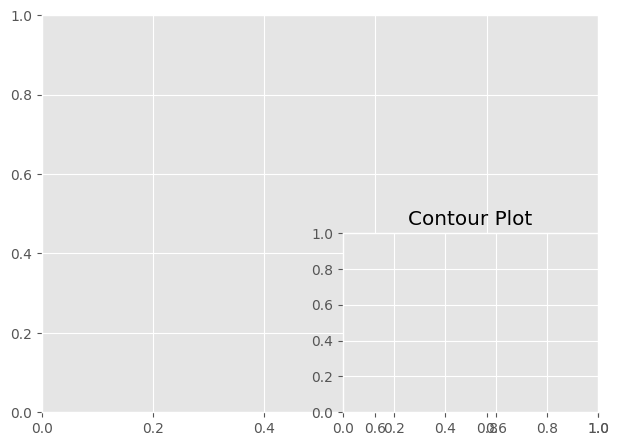

In [17]:
import warnings
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour,
)

# Suppress experimental warnings
warnings.filterwarnings('ignore', category=optuna.exceptions.ExperimentalWarning)

print(f"Study: {study.study_name} | Direction: {study.direction} | Trials: {len(study.trials)}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Optimization history
try:
    plot_optimization_history(study)
    plt.subplot(2, 2, 1)
    plt.title('Optimization History')
except Exception as e:
    axes[0, 0].text(0.5, 0.5, f"Optimization history\nfailed:\n{e}", ha="center")
    axes[0, 0].axis("off")

# Parameter importances
try:
    plot_param_importances(study)
    plt.subplot(2, 2, 2)
    plt.title('Parameter Importances')
except Exception as e:
    axes[0, 1].text(0.5, 0.5, f"Param importances\nfailed:\n{e}", ha="center")
    axes[0, 1].axis("off")

# Parallel coordinate (may require multiple params/trials)
try:
    plot_parallel_coordinate(study)
    plt.subplot(2, 2, 3)
    plt.title('Parallel Coordinate')
except Exception as e:
    axes[1, 0].text(0.5, 0.5, f"Parallel coordinate\nfailed:\n{e}", ha="center")
    axes[1, 0].axis("off")

# Contour (pairwise relationships)
try:
    plot_contour(study)
    plt.subplot(2, 2, 4)
    plt.title('Contour Plot')
except Exception as e:
    axes[1, 1].text(0.5, 0.5, f"Contour plot\nfailed:\n{e}", ha="center")
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()
